<h1 align="center"> 🏥 Healthcare Premium Analysis </h1>

## Objective
The goal of this notebook is to analyze healthcare insurance data, perform data preprocessing, and identify key factors influencing premium prediction.

This serves as the foundation for building a robust machine learning model.

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

## EDA

### 📂 Load Dataset

In [103]:
df=pd.read_excel("C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/project_1_datacleaning_&_EDA_resources/premiums.xlsx")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [104]:
df.shape

(50000, 13)

In [105]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

To change column names to consistent format:

In [106]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [107]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    50000 non-null  int64 
 1   gender                 50000 non-null  object
 2   region                 50000 non-null  object
 3   marital_status         50000 non-null  object
 4   number_of_dependants   50000 non-null  int64 
 5   bmi_category           50000 non-null  object
 6   smoking_status         49989 non-null  object
 7   employment_status      49998 non-null  object
 8   income_level           49987 non-null  object
 9   income_lakhs           50000 non-null  int64 
 10  medical_history        50000 non-null  object
 11  insurance_plan         50000 non-null  object
 12  annual_premium_amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


### Insight
- Dataset contains numerical and categorical features related to demographics, income, and medical history.
- Target variable: `premium_amount`

<h2 align="center">🧹 Data Cleaning</h3>

### 1. Handling NA Values

In [109]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

if we consider the overall size of the dataset, these na values arent many. So the best thing to do is discard those rows. 

In [110]:
df.dropna(inplace=True)

### 2. Duplicate Records

In [111]:
df.duplicated().sum()

0

In [112]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

### 3. Invalid Values

In [113]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [114]:
df[df.number_of_dependants<0].shape

(72, 13)

In [115]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-3, -1], dtype=int64)

This would have occured probably because there was a bug in the data collection script. Instead of 1 and 3, it would have been saved -1 and -3.

In [116]:
df["number_of_dependants"]=abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

Negative dependents were corrected as they are logically invalid.

In [117]:
numeric_columns=df.select_dtypes(["float64","int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

### 📊 Outlier Treatment

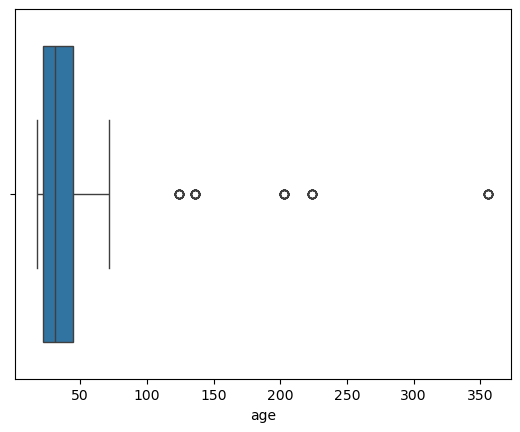

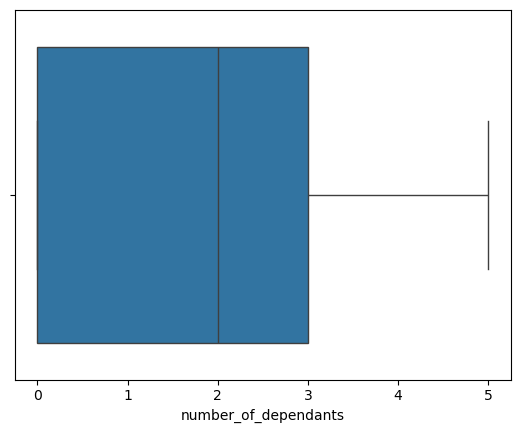

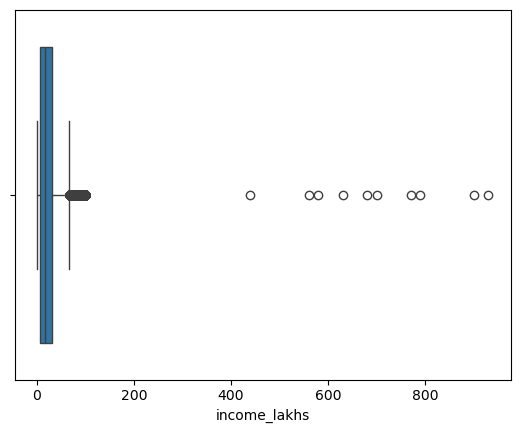

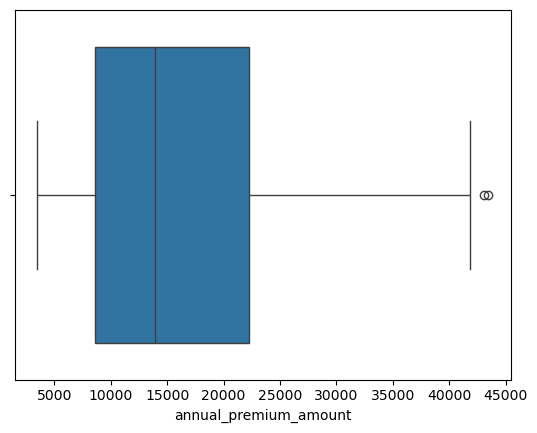

In [118]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

##### age

In [119]:
df[df.age>100].age.unique()

array([224, 124, 136, 203, 356], dtype=int64)

the best thing to do is drop these rows because we dont know what the ages of these people are.

In [120]:
df1=df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


##### Income

In [121]:
df.income_lakhs.quantile([0.25,0.75])

0.25     7.0
0.75    31.0
Name: income_lakhs, dtype: float64

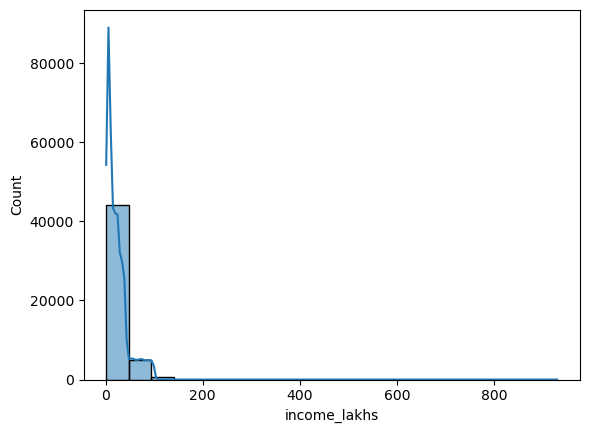

In [122]:
sns.histplot(df["income_lakhs"],kde=True,bins=20)
plt.show()

In [123]:
def get_IQR_bounds(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return lower_bound,upper_bound

In [124]:
get_IQR_bounds(df1.income_lakhs)

(-29.0, 67.0)

We dont have to worry about lower bound because min income is anyway 1. However on the upper side the bound i am getting is 67. So any value above 67 can be considered outliers.

In [125]:
df1.income_lakhs.quantile(0.9)

54.0

which is less than upper bound value

In [126]:
quantile_threshold=df1.income_lakhs.quantile(0.999)
quantile_threshold

100.0

In [127]:
df1[df1.income_lakhs>quantile_threshold]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
2635,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4220,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
7775,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
9021,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
10337,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
10639,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
11456,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
15437,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
35446,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
40970,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


In [128]:
df1[df1.income_lakhs>quantile_threshold].shape

(10, 13)

since its just 10 people having income greater than 1 crore, we can drop them. 
That means you kept 99.9% of the data and removed the extreme 0.1% tail. In many practical datasets, that’s a reasonable first cut, especially if the dataset is large.

In [129]:
df2=df1[df1.income_lakhs<=quantile_threshold].copy()

In [130]:
df2.shape

(49908, 13)

In [131]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


### Numeric Columns Analysis

#### Univariate Analysis

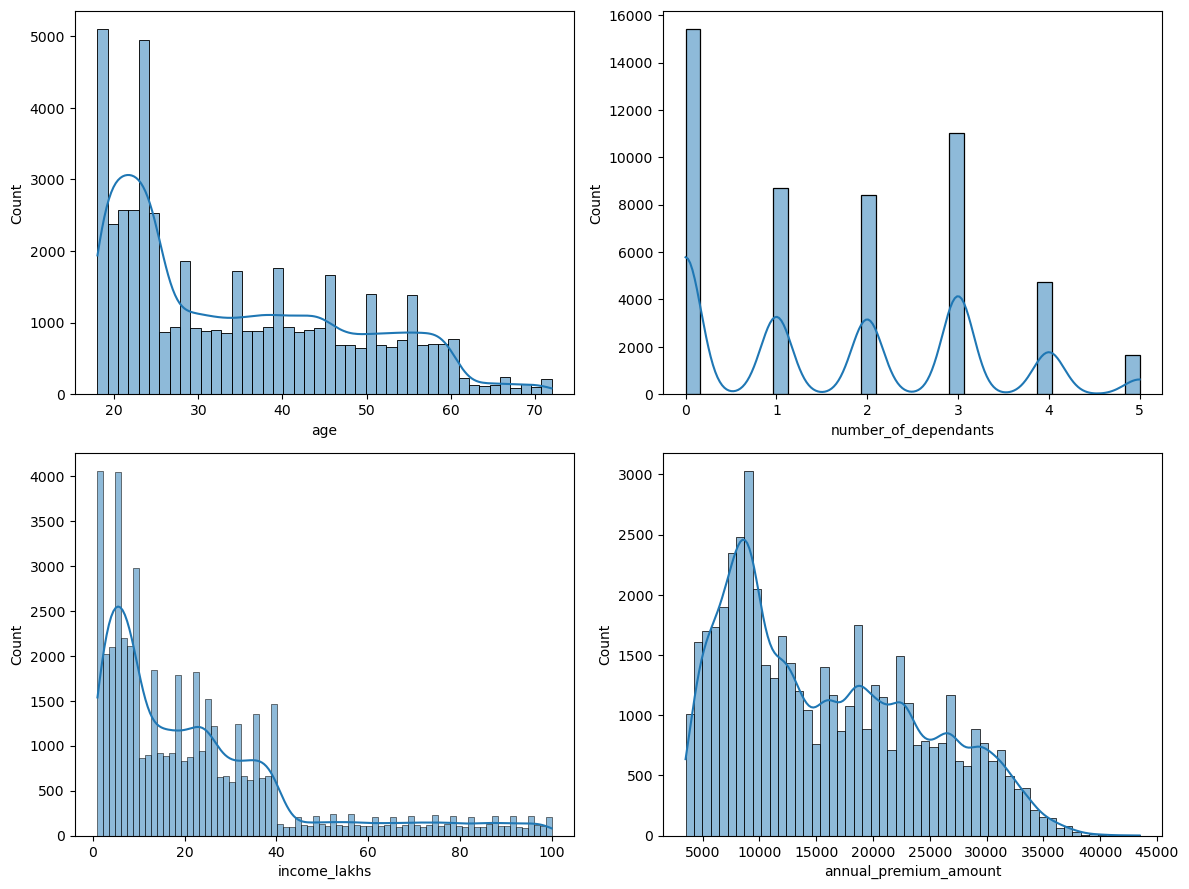

In [132]:
plt.figure(figsize=(12,9))
for i,col in enumerate(numeric_columns):
    plt.subplot(2,2,i+1)
    sns.histplot(x=df2[col],kde=True)
plt.tight_layout()
plt.show()

#### Bivariate Analysis

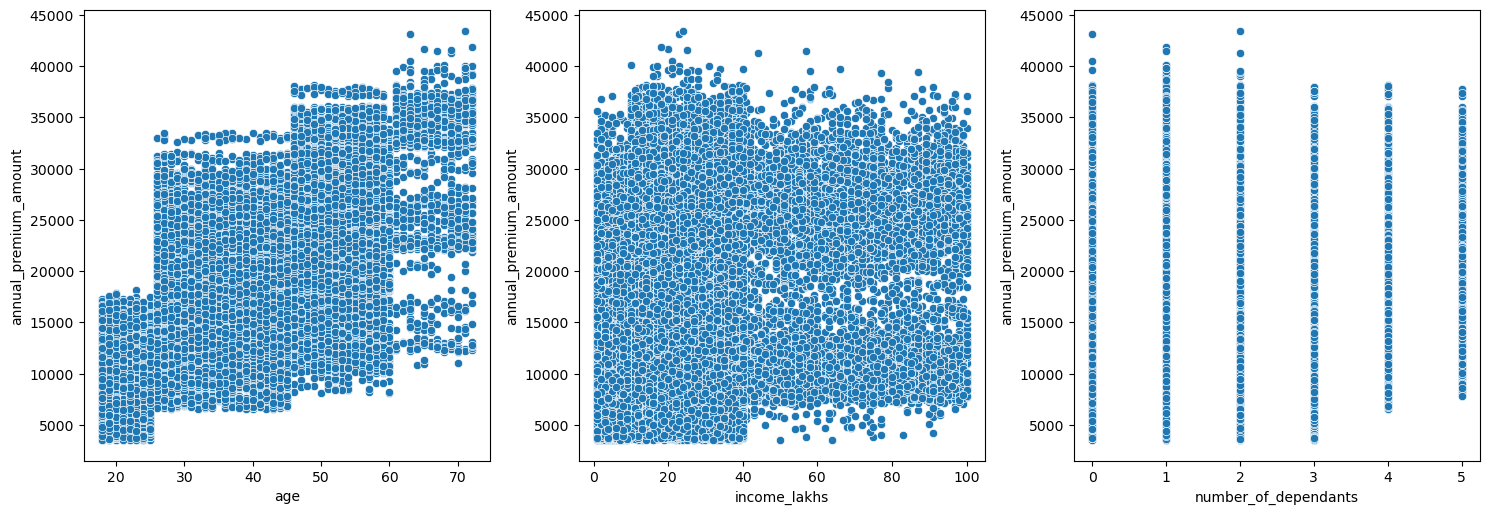

In [133]:
plt.figure(figsize=(15,15))
features = ["age", "income_lakhs", "number_of_dependants"]
for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(df2,x=col,y="annual_premium_amount")
plt.tight_layout()
plt.show()

### Categorical Columns Analysis

In [134]:
categorical_col=df.select_dtypes(include=["object","category"]).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [135]:
for col in categorical_col:
    print(col,":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


smoking_status : ['No Smoking' 'Smoking=0' 'Does Not Smoke' 'Not Smoking'] - here we can see an invalid category "Smoking=0". 

No Smoking, Smoking=0, Does Not Smoke, Not Smoking is all the same which is "Does Not Smoke".

In [136]:
df2["smoking_status"]=df2["smoking_status"].replace({
    'Smoking=0':"No Smoking",
    'Does Not Smoke':"No Smoking",
    'Not Smoking':'No Smoking'
})
df2.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

#### Univariate Analysis

In [137]:
pct_count=df2["gender"].value_counts(normalize=True)*100
pct_count

gender
Male      54.963132
Female    45.036868
Name: proportion, dtype: float64

normalize=True means convert counts into proportions (fractions of the total).

<Axes: xlabel='gender'>

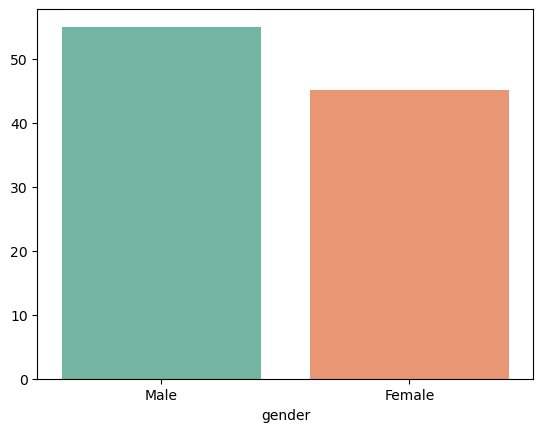

In [138]:
sns.barplot(x=pct_count.index,y=pct_count.values,hue=pct_count.index,palette="Set2")

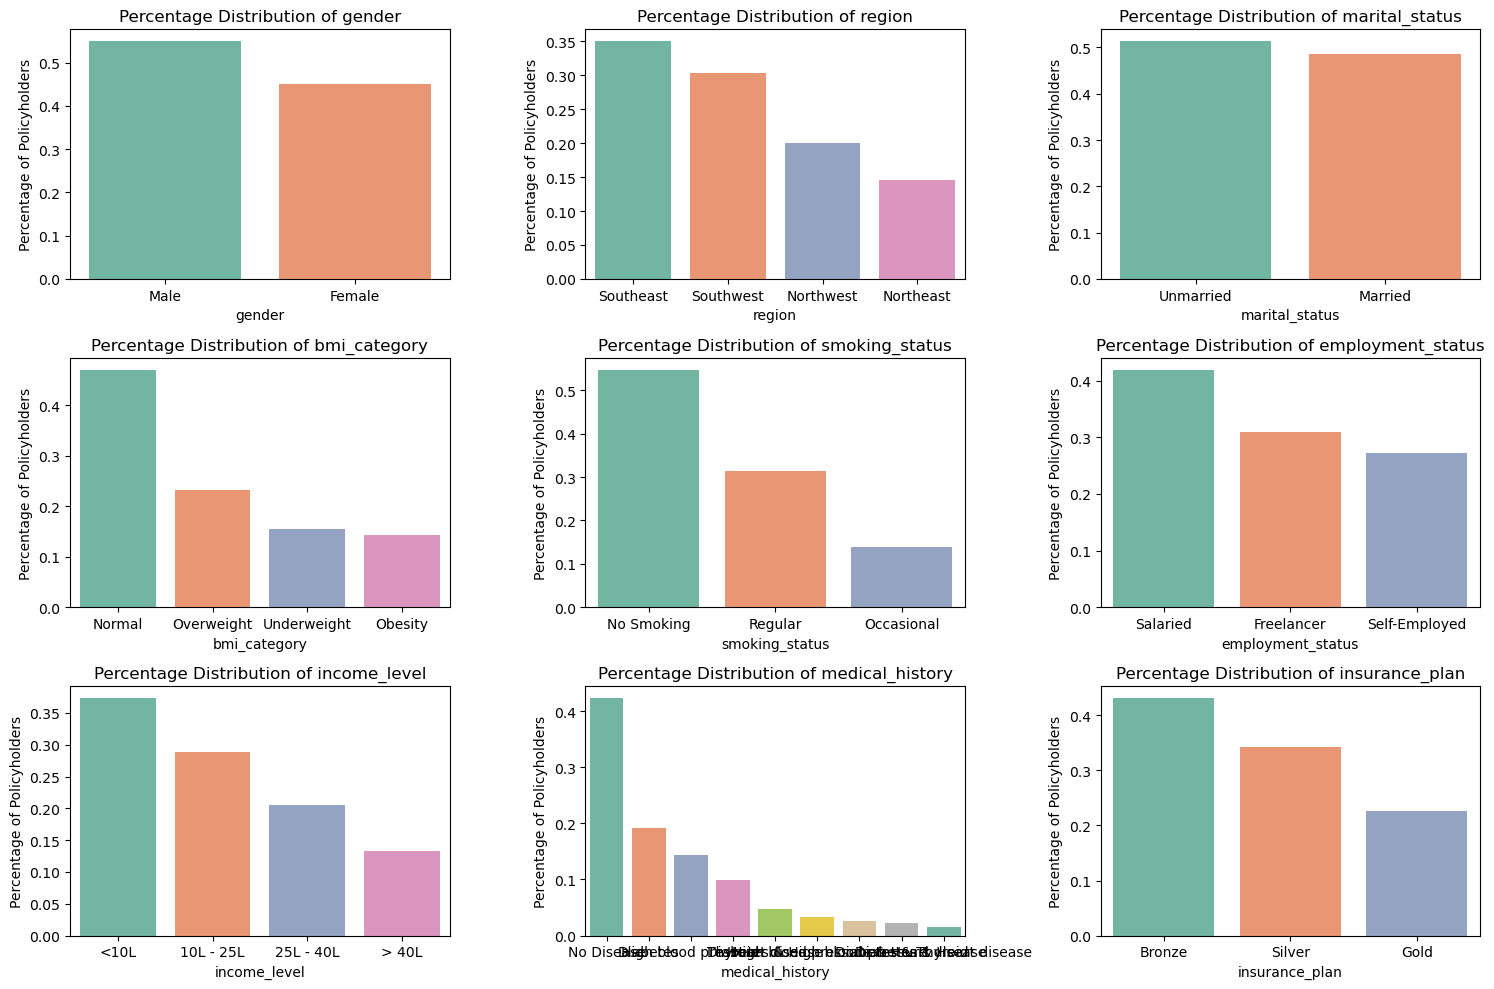

In [139]:
plt.figure(figsize=(15,10))
for i,col in enumerate(categorical_col):
    pct_count=df2[col].value_counts(normalize=True)
    plt.subplot(3,3,i+1)
    sns.barplot(x=pct_count.index,y=pct_count.values,hue=pct_count.index,palette="Set2")
    plt.title(f"Percentage Distribution of {col}")
    plt.ylabel("Percentage of Policyholders")
    plt.xlabel(col)
plt.tight_layout()
plt.show()
    

#### Bivariate Analysis

In [140]:
crosstab=pd.crosstab(df2["income_level"],df2["insurance_plan"])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


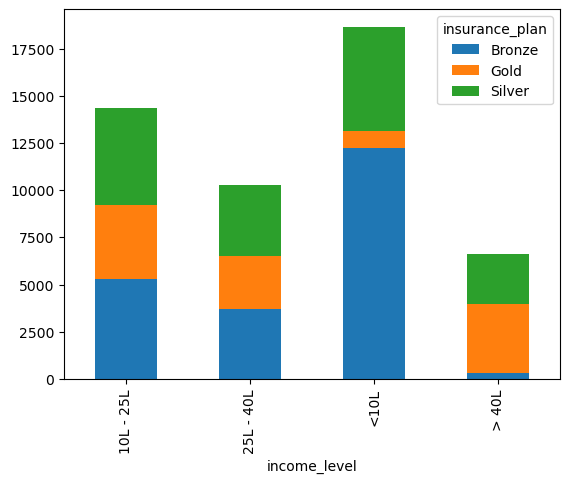

In [141]:
crosstab.plot(kind="bar",stacked=True)
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

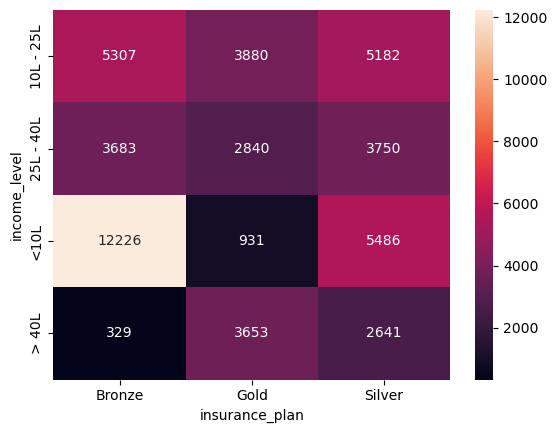

In [142]:
sns.heatmap(crosstab,annot=True,fmt='d')

<h2 align="center"> ⚙️ Feature Engineering</h2>

In [143]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


### Calculate Risk Score

In [144]:
risk_scores={
    "diabetes":6,
    "heart disease":8,
    "high blood pressure":6,
    "thyroid":5,
    "no disease":0,
    "none":0
}

df2[["disease 1","disease 2"]]=df2["medical_history"].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,None
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,None


In [145]:
df2["disease 1"]=df2["disease 1"].fillna("none")
df2["disease 2"]=df2["disease 2"].fillna("none")

#Create a new column for total risk
df2["total_risk_score"]=0

#Convert diseases to risk scores
for disease in ["disease 1","disease 2"]:
    df2["total_risk_score"]+=df2[disease].map(risk_scores)    


### Normalisng Risk Score 

In [146]:
max_score=df2["total_risk_score"].max()
min_score=df2["total_risk_score"].min()
df2["normalised_risk_score"]=(df2["total_risk_score"] - min_score) / (max_score - min_score)
df2.head(10)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
5,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,none,6,0.428571
6,33,Male,Southeast,Married,3,Normal,Regular,Self-Employed,<10L,4,Diabetes & High blood pressure,Silver,20653,diabetes,high blood pressure,12,0.857143
7,43,Male,Northeast,Married,3,Overweight,Regular,Salaried,> 40L,46,Thyroid,Gold,26926,thyroid,none,5,0.357143
8,59,Female,Southeast,Unmarried,0,Overweight,No Smoking,Freelancer,10L - 25L,21,No Disease,Gold,26101,no disease,none,0,0.000000
9,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000


Risk-based features were engineered to better capture health-related premium variations.

In [147]:
df2.shape

(49908, 17)

### Ordinal encoding for ordered categories

#### insurance plan

In [148]:
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [149]:
df2["insurance_plan"]=df2["insurance_plan"].map({
    "Bronze":1,
    "Silver":2,
    "Gold":3
})

#### income level

In [150]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [151]:
df2["income_level"]=df2["income_level"].map({
    '<10L':1,
    "10L - 25L":2,
    "25L - 40L":3,
    "> 40L":4,
    
})

### One-hot encoding for nominal features

In [152]:
nominal_cols=["gender","region","marital_status","bmi_category","smoking_status","employment_status"]
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1


## Feature Selection

In [153]:
df4=df3.drop(columns=["medical_history","disease 1","disease 2","total_risk_score"])
df4

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,0,3,35,1,9111,0.000000,0,1,0,0,1,0,0,1,0,0,0,1
49996,47,2,4,82,3,27076,0.357143,0,0,1,0,0,0,0,0,0,0,1,0
49997,21,0,3,32,1,8564,0.000000,1,1,0,0,1,0,0,0,0,1,0,0
49998,18,2,2,20,1,9490,0.000000,1,1,0,0,1,0,0,0,0,0,1,0


## 📊 Correlation Analysis

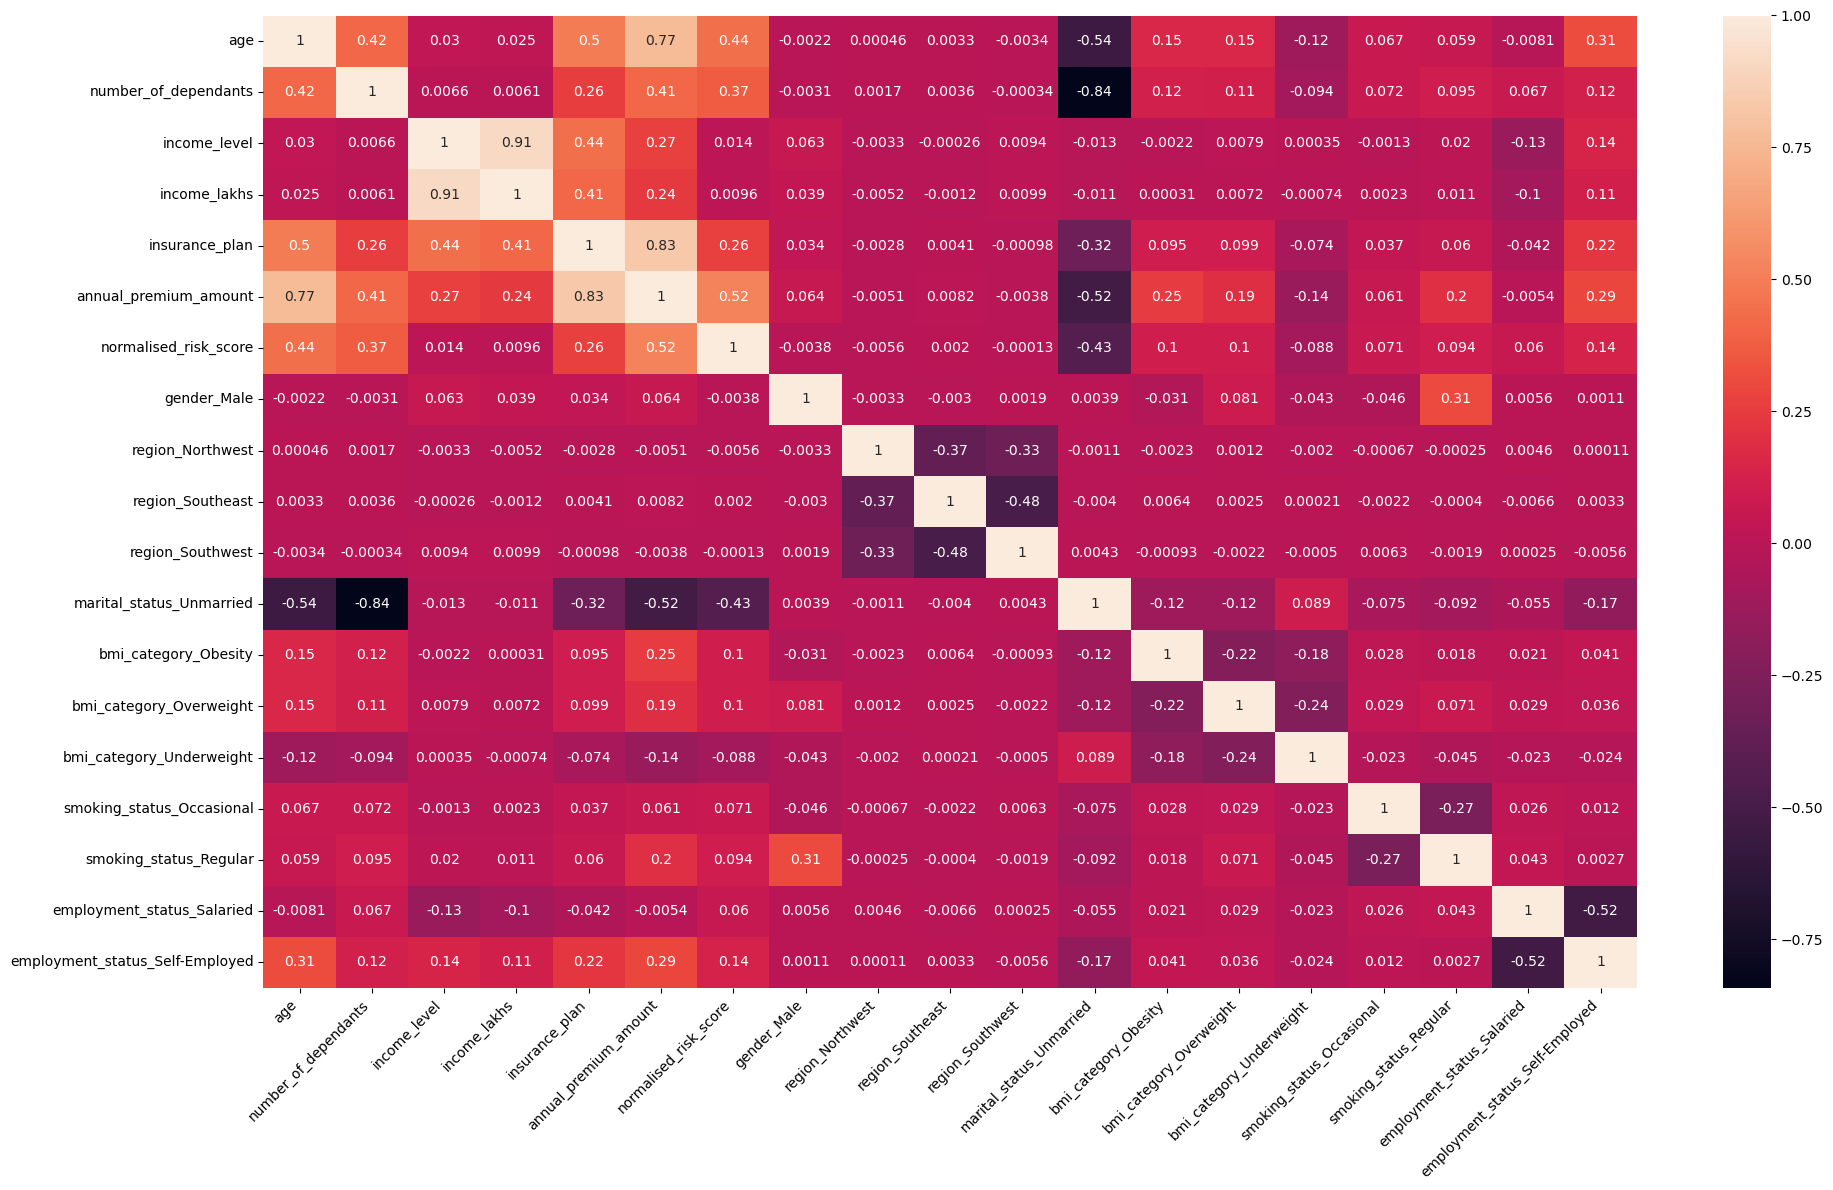

In [154]:
cm=df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight
Strong correlations observed between:
- Age and premium
- Risk score and premium

## Scaling Numerical Columns

In [155]:
X=df4.drop("annual_premium_amount",axis=1)
y=df4["annual_premium_amount"]

cols_to_scale=["age","number_of_dependants","income_lakhs","income_level","insurance_plan"]
scaler=MinMaxScaler()

X[cols_to_scale]=scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [156]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Feature Selection using VIF

To reduce multicollinearity, VIF was used to identify highly correlated features.

Features with high VIF were iteratively removed to improve model stability and interpretability.

In [157]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [158]:
calculate_vif(X)

,Columns,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalised_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [159]:
calculate_vif(X.drop("income_level",axis=1))

,Columns,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalised_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


Now VIF is less than 10 for all columns

In [160]:
X_reduced=X.drop("income_level",axis=1)
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


<h2 align="center"> Model Training</h2>

In [161]:
X_train,x_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=10)

In [162]:
X_train.shape

(34935, 17)

In [163]:
x_test.shape

(14973, 17)

### Linear Regression

In [164]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
test_score=model_lr.score(x_test,y_test)
test_score

0.9280547230217837

In [165]:
y_pred=model_lr.predict(x_test)
mse_lr=mean_squared_error(y_test,y_pred)
rmse_lr=np.sqrt(mse_lr)
print("Linear Regression ==> MSE:",mse_lr,"RMSE:",rmse_lr)

Linear Regression ==> MSE: 5165611.913027982 RMSE: 2272.798256121291


In [166]:
x_test.head(1)

,age,number_of_dependants,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
3598,0.481481,0.4,0.343434,0.5,0.428571,1,0,1,0,1,0,1,0,0,1,1,0


In [167]:
model_lr.intercept_

4824.300272127062

In [168]:
model_lr.coef_

array([11160.92646188,  -676.44399066,  -514.22981577, 12557.01293645,
        4810.35770228,   168.64666183,   -35.7192924 ,    39.96512973,
         -24.65292857,  -935.76061134,  3387.91145477,  1599.36226775,
         391.1713038 ,   735.91227798,  2234.8047119 ,   155.9846743 ,
         415.90397305])

In [169]:
feature_importances=model_lr.coef_

In [170]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
marital_status_Unmarried,-935.760611
number_of_dependants,-676.443991
income_lakhs,-514.229816
region_Northwest,-35.719292
region_Southwest,-24.652929
region_Southeast,39.965130
employment_status_Salaried,155.984674
gender_Male,168.646662
bmi_category_Underweight,391.171304
employment_status_Self-Employed,415.903973


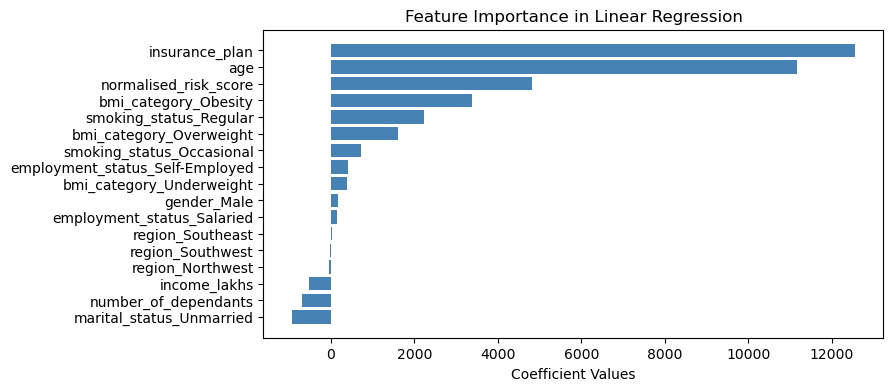

In [171]:
plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Linear Regression")
plt.show()

We can see from above insurance plan has maximum weightage, then age. When we deploy this model in production environment and we are doing prediction, at that time this bar chart will help to interpret the results.


### Ridge Regression

Used to handle multicollinearity and prevent overfitting.

In [172]:
model_rg=Ridge()
model_rg.fit(X_train,y_train)
test_score=model_rg.score(x_test,y_test)
test_score

0.9280541644640345

In [173]:
y_pred=model_rg.predict(x_test)
mse_rg=mean_squared_error(y_test,y_pred)
rmse_rg=np.sqrt(mse_rg)
print("Ridge Regression ==> MSE:",mse_rg,"RMSE:",rmse_rg)

Ridge Regression ==> MSE: 5165652.017016523 RMSE: 2272.8070787060924


In [174]:
model_rg=Ridge(alpha=10)
model_rg.fit(X_train,y_train)
test_score=model_rg.score(x_test,y_test)
test_score

0.9280459054997704

In [175]:
y_pred=model_rg.predict(x_test)
mse_rg=mean_squared_error(y_test,y_pred)
rmse_rg=np.sqrt(mse_rg)
print("Ridge Regression ==> MSE:",mse_rg,"RMSE:",rmse_rg)

Ridge Regression ==> MSE: 5166245.003880764 RMSE: 2272.93752749185


### XGBoost

Used for capturing non-linear relationships and improving predictive performance.

In [176]:
model_xgb=XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train,y_train)
test_score=model_xgb.score(x_test,y_test)
test_score

0.9782300591468811

with xgboost we got accuracy of 98%

In [177]:
y_pred=model_xgb.predict(x_test)
mse_xgb=mean_squared_error(y_test,y_pred)
rmse_xgb=np.sqrt(mse_xgb)
print("XGB Regression ==> MSE:",mse_xgb,"RMSE:",rmse_xgb)

XGB Regression ==> MSE: 1563064.0 RMSE: 1250.2255796455295


### Random Search CV: XGBoost

In [178]:
model_xgb=XGBRegressor()

param_grid={
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_

0.9809474547704061

In [179]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

best_estimator_ gives the model with best parameters

In [180]:
best_model=random_search.best_estimator_
y_pred=best_model.predict(x_test)
mse_xgb=mean_squared_error(y_test,y_pred)
rmse_xgb=np.sqrt(mse_xgb)
print("XGB Regression ==> MSE:",mse_xgb,"RMSE:",rmse_xgb)

XGB Regression ==> MSE: 1351649.625 RMSE: 1162.6046727069352


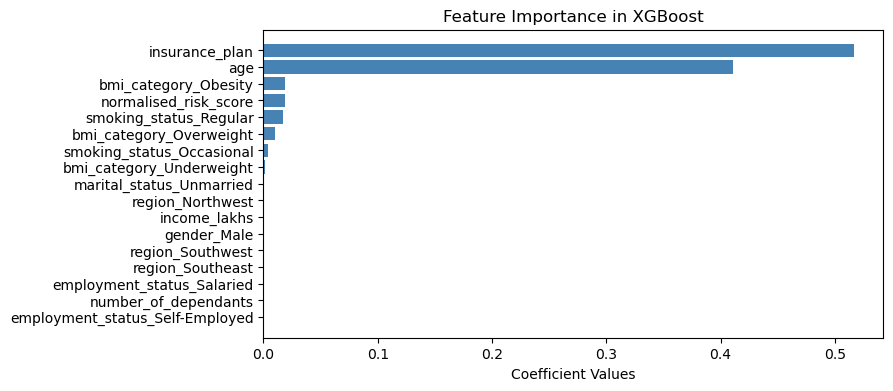

In [181]:
best_model=random_search.best_estimator_
feature_importances=best_model.feature_importances_

coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in XGBoost")
plt.show()

If we compare the feature importance bar chart of Linear Regression and XGBoost, we can see that feature importance vector of XGBoost is as not good as Linear Regression. 
Normalised risk score has importance in LR whearas in XGB its given less importance. 
XGB feature imp vectors are not as good as LR in terms of explanability because XGB is a tree based model.

<h2> Model Evaluation</h2>

| Model                | MSE | RMSE |R2|
|:---------------------|:----: |:--: |:-------:|
|Linear               |5165611.91| 2272.80  |0.93|
|Ridge                |5166245.00   | 2272.94  |0.92|
|XGBoost              |1563064.0    | 1250.23  |0.98|
|XGBoost Random Search |1351649.62     | 1162.60  |0.98|


### Insight:
- XGBoost performed best in terms of accuracy
- Linear models provided better interpretability

<h1 align="Center">Error Analysis</h1>

In [182]:
y_pred=best_model.predict(x_test)

residuals=y_pred-y_test
residuals_pct=residuals*100/y_test

results_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
3598,20554,20334.953125,-219.046875,-1.065714
35794,29647,29378.779297,-268.220703,-0.904714
43608,20560,20618.185547,58.185547,0.283004
42730,5018,7352.829590,2334.829590,46.529087
18936,8929,8203.291992,-725.708008,-8.127540


<Axes: xlabel='diff_pct', ylabel='Count'>

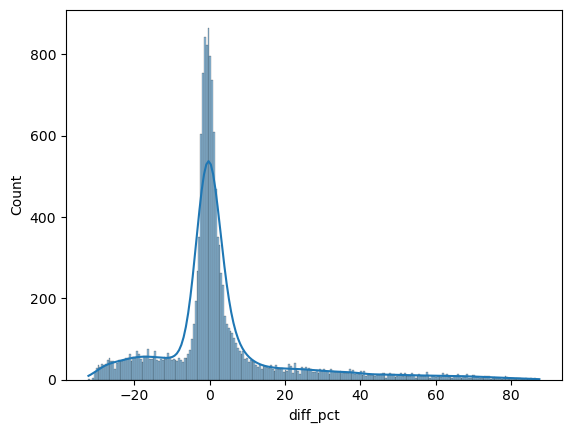

In [183]:
sns.histplot(results_df["diff_pct"],kde=True)

From the above fig we can see we have cases where diff_pct is higher than   20%. For instance we have cases where predicted premium is 80% higher than actual whch is not good.

In [184]:
extreme_error_threshold=10
extreme_results_df=results_df[np.abs(results_df["diff_pct"])>extreme_error_threshold]
extreme_results_df.shape

(4487, 4)

In [185]:
results_df.shape

(14973, 4)

In [186]:
(extreme_results_df.shape[0]*100)/results_df.shape[0]

29.967274427302478

We have 30% extreme errors which means for 30% customers we will either overcharge or undercharge by 10% or more

In [187]:
results_df[np.abs(results_df["diff_pct"]>50)].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
36269,3501,6565.852051,3064.852051,87.542189
48801,3516,6565.852051,3049.852051,86.742095
42342,3521,6565.852051,3044.852051,86.476911
18564,3523,6565.852051,3042.852051,86.371049
7988,3527,6565.852051,3038.852051,86.159684
...,...,...,...,...
32671,4656,6994.980957,2338.980957,50.235845
14798,4371,6565.852051,2194.852051,50.213957
13736,4371,6565.852051,2194.852051,50.213957
10107,4710,7073.240723,2363.240723,50.174962


if we have a look at the first row, we can see the error diff. pred=6565.852051 actual=3501 which is not good. we clearly have a problem and we cant deploy this model. So to get rows with actual features,we do as belows:

In [188]:
extreme_error_df=x_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.428571,1,0,0,0,1,0,1,0,0,0,0,0
20029,0.018519,0.2,0.030303,0.0,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.000000,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.000000,0,0,0,0,1,0,0,1,0,0,0,0
6707,0.111111,0.2,0.070707,0.5,0.000000,1,0,0,0,1,0,0,1,0,0,0,0


### Residual Plot

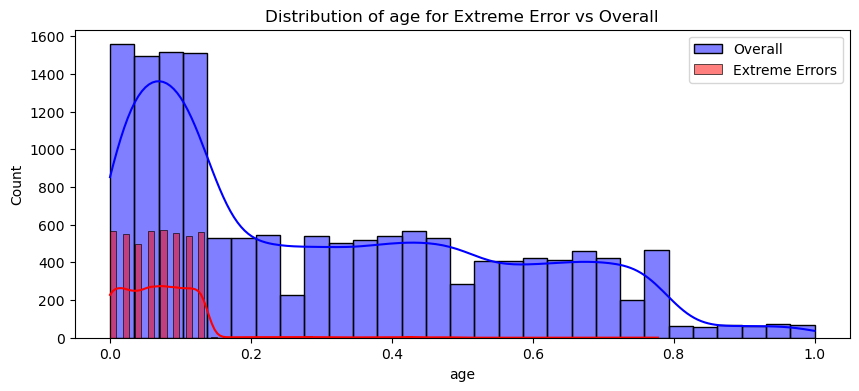

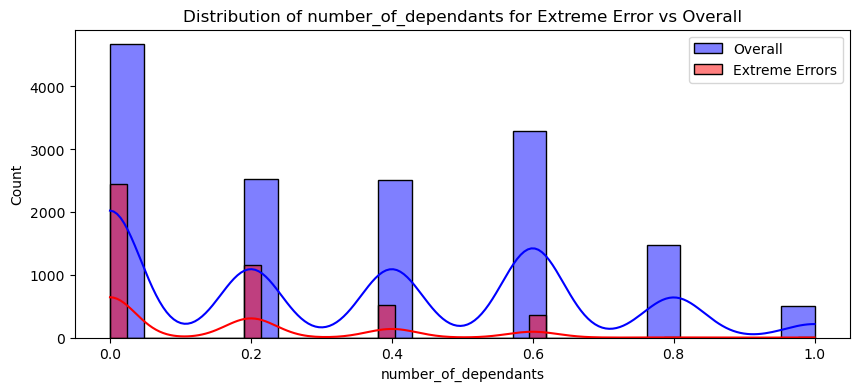

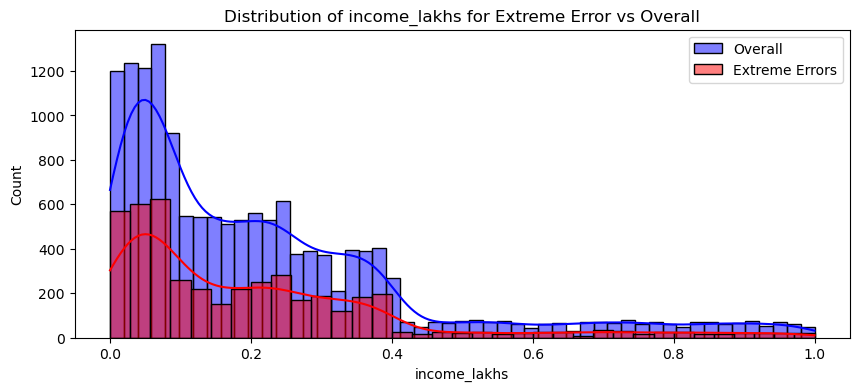

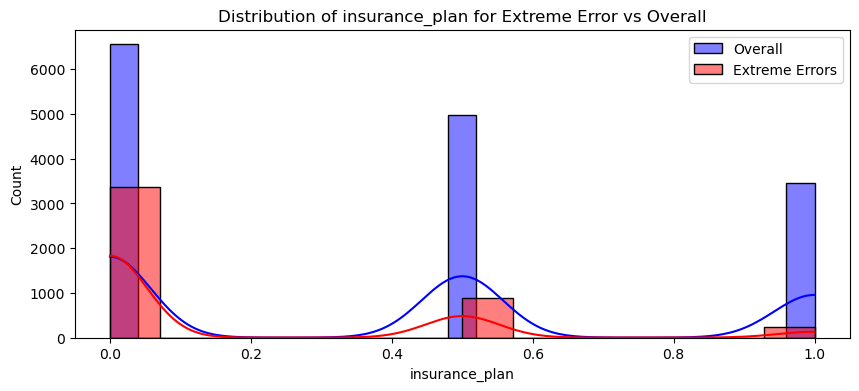

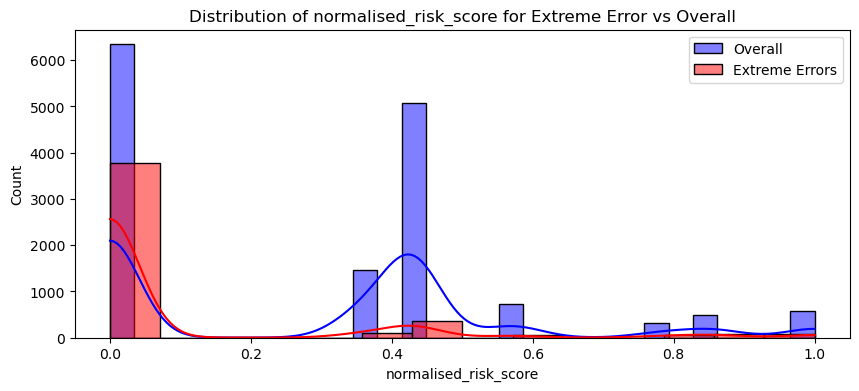

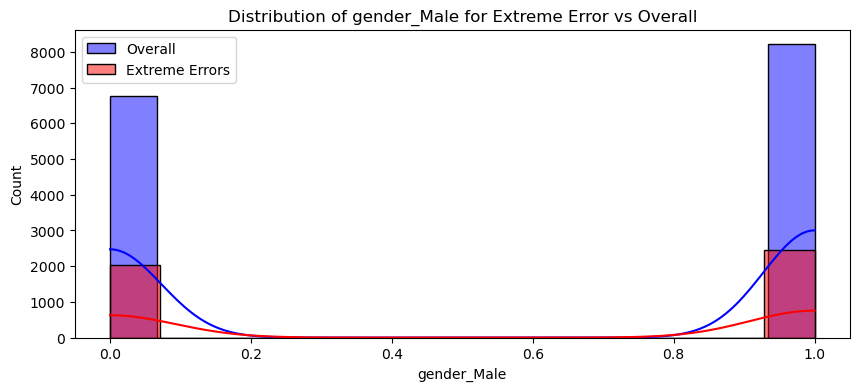

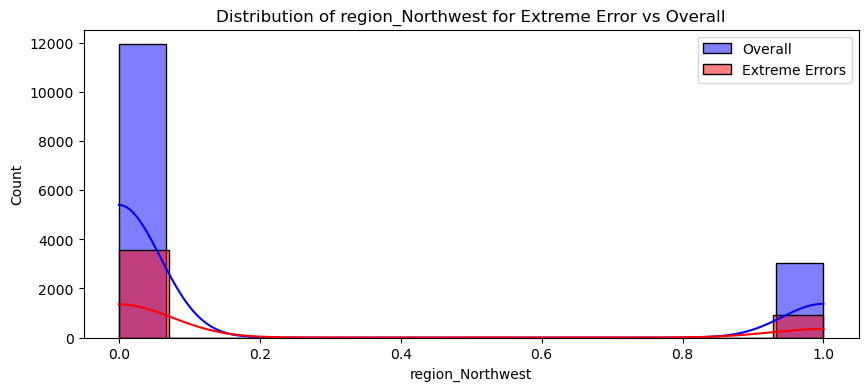

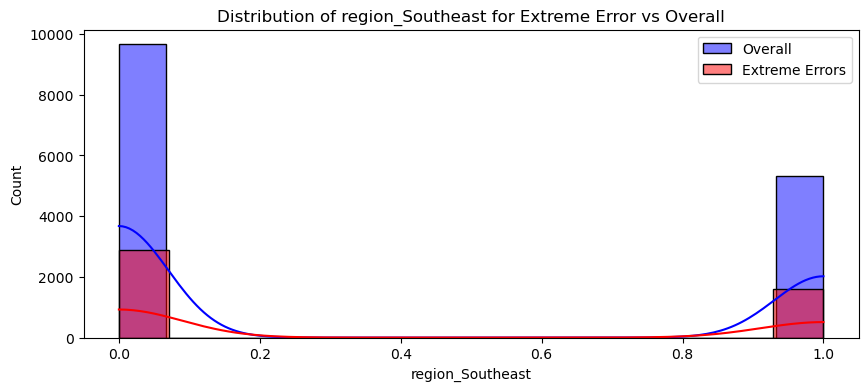

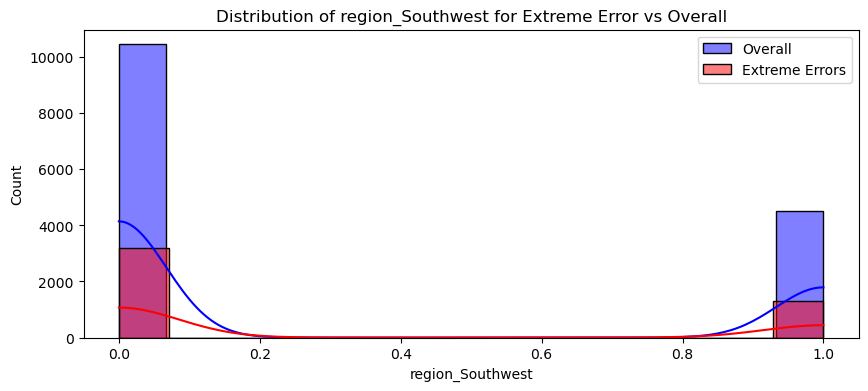

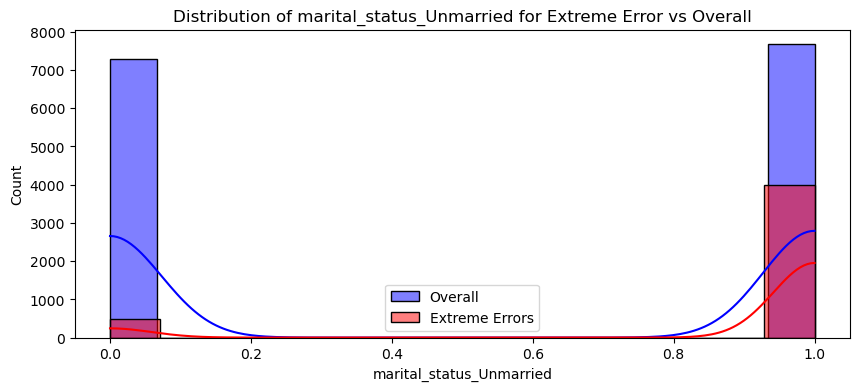

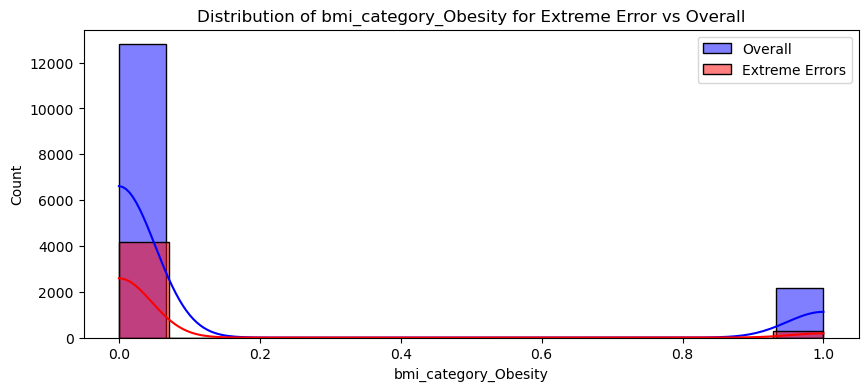

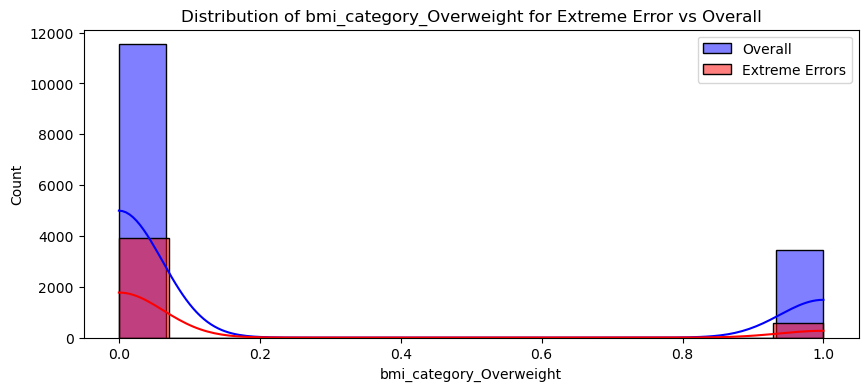

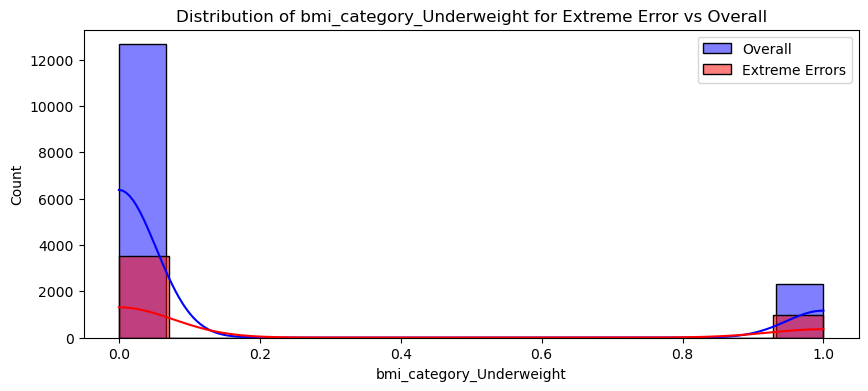

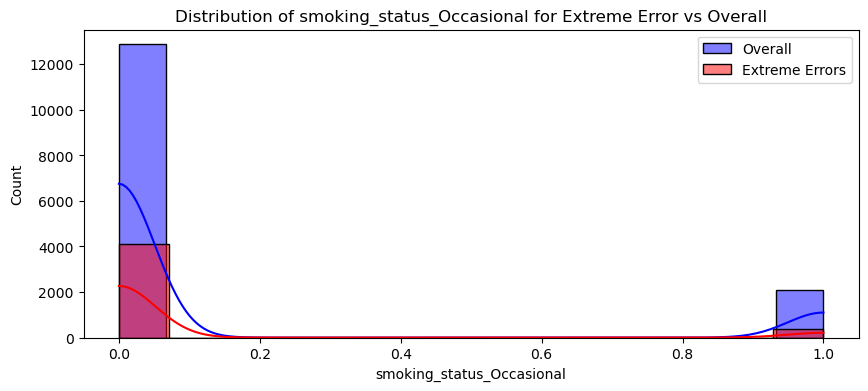

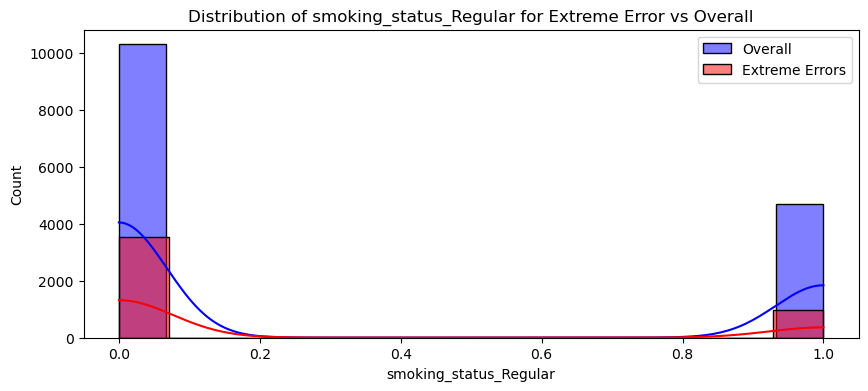

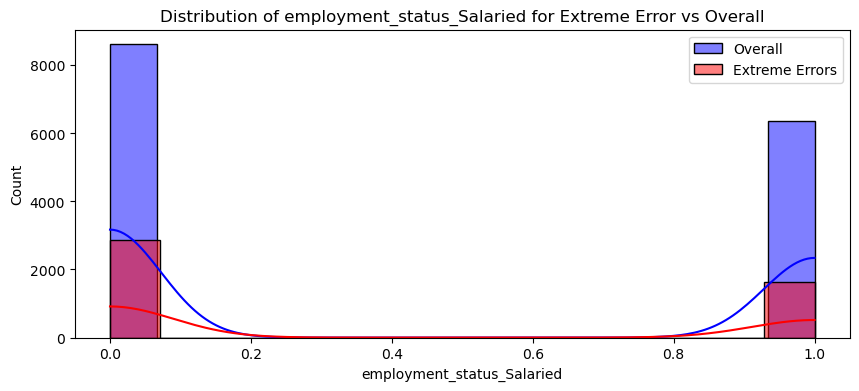

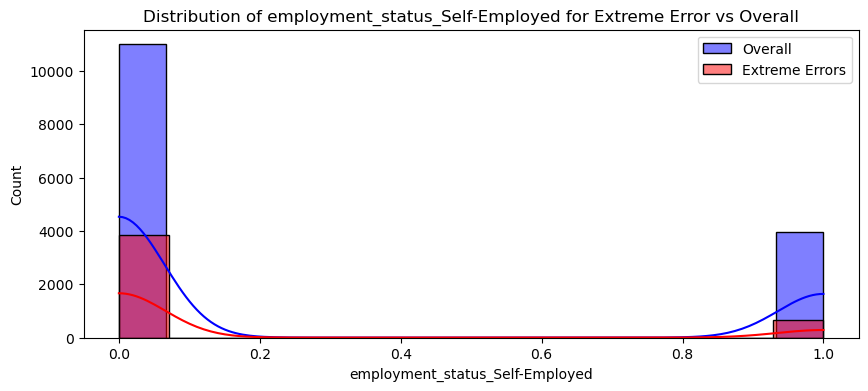

In [189]:
for feature in x_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(x_test[feature],label="Overall",kde=True,color="blue",alpha=0.5)
    sns.histplot(extreme_error_df[feature],label="Extreme Errors",kde=True,color="Red")
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Error vs Overall")
    plt.show()

### Error Analysis Insights

- Approximately 30% of predictions show more than 10% error
- Some predictions deviate significantly (up to 50–80%)
- Residuals are not randomly distributed

This indicates that the model is not capturing all underlying patterns effectively. Most of the distributions are similar except for age. We can see lower age group has extreme errors.

### Reverse Scaling

In [190]:
cols_to_scale

['age',
 'number_of_dependants',
 'income_lakhs',
 'income_level',
 'insurance_plan']

In [191]:
extreme_error_df["income_level"]=-1

In [192]:
df_reversed=pd.DataFrame()
df_reversed[cols_to_scale]=scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed

,age,number_of_dependants,income_lakhs,income_level,insurance_plan
0,23.0,1.0,14.0,-2.0,1.0
1,19.0,1.0,4.0,-2.0,1.0
2,18.0,1.0,3.0,-2.0,1.0
3,21.0,0.0,25.0,-2.0,1.0
4,24.0,1.0,8.0,-2.0,2.0
...,...,...,...,...,...
4482,19.0,1.0,8.0,-2.0,1.0
4483,25.0,0.0,12.0,-2.0,1.0
4484,21.0,0.0,7.0,-2.0,2.0
4485,21.0,1.0,8.0,-2.0,1.0


<Axes: xlabel='age', ylabel='Count'>

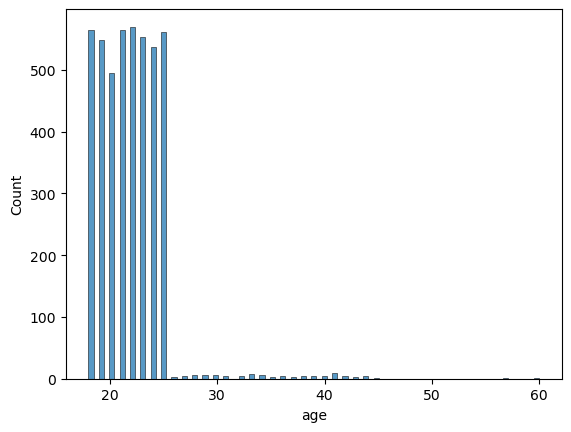

In [193]:
sns.histplot(df_reversed.age)

We can see upto 25 years age we have a problem.

### Key Insight

The presence of large and systematic prediction errors suggests that a single global model is insufficient.

The model struggles to generalize across different groups within the dataset.

### Hypothesis

Different age groups may exhibit different healthcare premium patterns due to varying risk profiles.

### Proposed Solution

Introduce a segmented modeling approach by dividing the dataset based on age and training separate models for each segment.

This is expected to improve prediction accuracy and reduce large errors.